# Fitting a lognormal PDF to the density diagnostic trend

This is yet another extension of the `density_diagnostic_trends` and `density_diagnostic_fit` notebooks, with the aim to repeat the analysis for a lognormal density distribution.

This is at the behest of Referees #1+#2

We already established that a *pure* lognormal will not work, since if the width is large enough (about 2 dex) to fit the density diagnostics, then the volume is totally dominated by very low density gas and the filling factor is absurdly low (< $10^{-9}$). So, we need to use a truncated lognormal, at least on the low-density side.  I am hoping that we will not need to truncate on the high-density side, so we can keep it as a 3-parameter model, the same as for the bimodal and power-law distributions. 

## Density diagnostic ratios from a log normal PDF

The log-normal density PDF is
$$
H_n =
\frac{H_0}{n\sigma\sqrt{2\pi}}
\exp\left[
-\frac{(\ln n-\mu)^2}{2\sigma^2}
\right]. \tag{LN-1}
$$
Note that there is a factor of $n^{-1}$ because $H_n$ is the PDF per linear density, whereas it is the PDF per log density, $H_{\ln n} = n H_n$ that is Gaussian. The normalization constant is $H_0 = 1$ for the untruncated case. For the lower-truncated case with minimum density $n_\min$, it is
<!-- $$
H_0 = \frac{2}{\mathrm{erfc}(z_\min / \sqrt{2})}
\quad
\text{where}
\quad
z_\min = \frac{\ln n_\min - \mu}{\sigma}
$$ -->
$$
H_0 = \frac{2}{\mathrm{erfc}\left( \frac{\ln n_\min - \mu}{\sqrt{2} \sigma}\right)} \tag{LN-2}
$$
where $\mathrm{erfc}$ is the complementary error function.  However, the normalization is not needed for the line ratios since it will always cancel. 

From equation (PDF-3) in `density-diagnostic-trends.ipynb` we have the normalized line ratio $\tilde{R} = R / R_\mathrm{lo}$ in terms of the normalized density $\tilde{n} = n / n_\mathcal{M}$:
$$
\tilde{R} = \frac{\int_0^\infty (1 + \delta\,\tilde{n})^{-1}\, H_\tilde{n} \, d\tilde{n}}{\int_0^\infty (1 + \delta^{-1}\,\tilde{n})^{-1}\, H_\tilde{n} \, d\tilde{n}}. \tag{PDF-3}
$$

This can be written as 
$$
\tilde{R} = \frac{\mathcal{I}(n_1)}{\mathcal{I}(n_2)}
$$
for $n_1 = \delta^{-1}\, n_\mathcal{M}$, $n_2 = \delta\, n_\mathcal{M}$
where
$$
\mathcal{I}(n_k)
=
\frac{H_0}{\sqrt{2\pi}}
\int_{z_{\min}}^\infty
\frac{e^{-z^2/2}}
{1 + \exp(\mu+\sigma z - \ln n_k)}
\,dz,
$$
with $ z = (\ln n - \mu) / \sigma$. 

In [1]:
import numpy as np
from astropy.table import Table
from matplotlib import pyplot as plt
import seaborn as sns
import corner
from lmfit import Model
import ddtrends as ddt
from orion_diagnostics import ori_tab

## Try out the PDF implementation

In [2]:
pdf = ddt.LogNormalPDF(100.0, 300.0, 2.0)

In [3]:
Rciii = ddt.ConcreteRatio(nM=10**6.7, delta=130, Rlo=1.55, label="[C III] 1907 / C III] 1909")
Rsii = ddt.ConcreteRatio(nM=10**3.06, delta=3.4**0.5, Rlo=1.44, label="[S II] 6716 / 6731")

In [4]:
ddt.apparent_density_lognormal(Rsii, pdf)

/Users/will/Dropbox/hii-density-distribution/ddtrends.py:369: RuntimeWarning: overflow encountered in exp
  n = np.exp(self.logn_mu + self.sigma * z)


600.0627399461875

In [5]:
ddt.apparent_density_lognormal(Rciii, pdf)

14379.837345673588

That seems to work ok

## Test efficient vectorized version

In [6]:
ddt.apparent_density_lognormal_vec(Rsii.nM, Rsii.delta, pdf)

array([600.06259712])

In [7]:
pdf.I(Rsii.nM * Rsii.delta)

0.6308360047580336

Check how many quadrature nodes we need

In [10]:
nk = Rsii.nM * Rsii.delta,
for nq in [8, 16, 24, 32, 48, 64]:
    result = pdf.I_vec(nk, nquad=nq)
    print(nq, result)

8 [0.61527691]
16 [0.63081107]
24 [0.63083865]
32 [0.63083596]
48 [0.630836]
64 [0.630836]


It looks like 16 is enough for convergence in this case, but we will still with 32 to be safe.

## Observational data

Grab the Eduardo data for Orion diagnostics versus n_M

In [11]:
subset = ori_tab["independent?"]
xdata = ori_tab[subset]["log10(n_M)"].data
ydata = ori_tab[subset]["log10(n_obs)"].data
xdata, ydata

(array([3.06, 3.16, 3.74, 3.84, 3.99, 4.85, 5.03, 6.19, 6.31]),
 array([2.309, 2.54 , 2.685, 2.395, 3.07 , 2.757, 2.942, 3.696, 3.333]))

In [12]:
def lognormal_model(x, log_n0, log_nmu, log_width):
    """
    Model function for log10_n_obs(log10_n_M) with parameters (log_n0, log_nmu, log_width)

    Suitable for use with lmfit.Model
    """

    # Set up diagnostic line ratio parameters
    nM = 10 ** x
    # Vary with nM = 1e3 -> 1e7 as delta = 2 -> 200
    delta = 2.0 * np.sqrt(nM / 1e3)

    # Set up power-law PDF
    log_n1 = log_n0 + log_width
    pdf = ddt.LogNormalPDF(10 ** log_n0, 10 ** log_nmu, log_width)

    # Find observed density using the vectorized function
    # n_obs = ddt.n_app_from_nM(nM, pdf, delta=delta)
    n_obs = ddt.apparent_density_lognormal_vec(nM, delta, pdf)

    return np.log10(n_obs)
    

lmodel = Model(lognormal_model)

Use similar broad priors for the parameters. 

In [13]:
params = lmodel.make_params(
    log_n0=dict(value=-1.0, min=-3, max=3.5),
    log_nmu=dict(value=-1.0, min=-3, max=3.5),
    log_width=dict(value=2.0, min=0.1, max=8),
)
params

name,value,initial value,min,max,vary
log_n0,-1.00000000,-1.0,-3.00000000,3.50000000,True
log_nmu,-1.00000000,-1.0,-3.00000000,3.50000000,True
log_width,2.00000000,2.0,0.10000000,8.00000000,True


Set uniform weights and do the fit

In [14]:
sig_y = 0.25 * np.ones_like(ydata)

## Perform the initial fit with Levenberg-Marquardt

In [15]:
result = lmodel.fit(ydata, params, x=xdata, weights=1 / sig_y)

In [16]:
from IPython.display import Markdown, display

def show_fit_md(result, heading="Fit result", level=4):
    hashes = "#" * level
    report = result.fit_report()
    display(Markdown(f"{hashes} {heading}\n\n```text\n{report}\n```"))



In [17]:
show_fit_md(result, heading="LMfit result", level=3)

### LMfit result

```text
[[Model]]
    Model(lognormal_model)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 47
    # data points      = 9
    # variables        = 3
    chi-square         = 6.36032283
    reduced chi-square = 1.06005380
    Akaike info crit   = 2.87569102
    Bayesian info crit = 3.46736475
    R-squared          = 0.75714915
[[Variables]]
    log_n0:     1.50161007 +/- 1.32511531 (88.25%) (init = -1)
    log_nmu:   -2.99999989 +/- 30.9136662 (1030.46%) (init = -1)
    log_width:  2.81296325 +/- 12.6706402 (450.44%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(log_nmu, log_width) = +0.9993
    C(log_n0, log_nmu)    = +0.9503
    C(log_n0, log_width)  = +0.9398
```

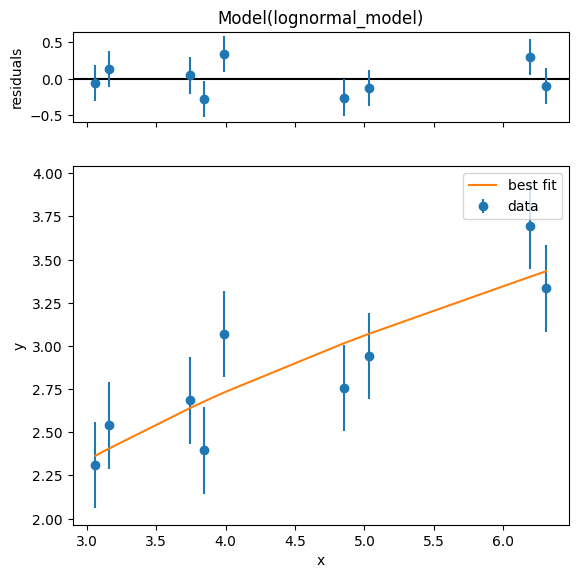

In [18]:
result.plot();

## Compare lognormal versus power law

In [19]:
result.params

name,value,standard error,relative error,initial value,min,max,vary
log_n0,1.50161007,1.32511531,(88.25%),-1.0,-3.00000000,3.50000000,True
log_nmu,-2.99999989,30.9136662,(1030.46%),-1.0,-3.00000000,3.50000000,True
log_width,2.81296325,12.6706402,(450.44%),2.0,0.10000000,8.00000000,True


In [20]:
ln_pdf = ddt.LogNormalPDF(10**1.5, 10**-3, 2.81)
pp_pdf = ddt.PowerLawPDF(-1.41, 10**1.74, 10**7.09)

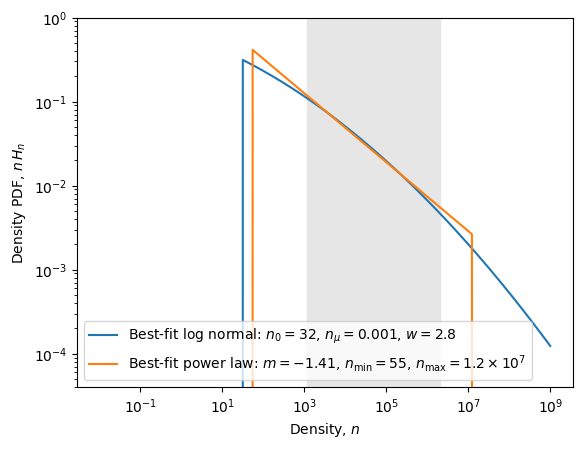

In [21]:
fig, ax = plt.subplots()
ngrid = np.geomspace(0.01, 1e9, 10000)
ymin = 2e-5
ln_y = ngrid * ln_pdf(ngrid)
pp_y = ngrid * pp_pdf(ngrid)
ln_y[~np.isfinite(ln_y)] = ymin
pp_y[~np.isfinite(pp_y)] = ymin
ax.plot(ngrid, ln_y, label=f"Best-fit log normal: {ln_pdf.label}")
ax.plot(ngrid, pp_y, label=f"Best-fit power law: {pp_pdf.label.replace("e+07", r"\times 10^{7}")}")
ax.set_xscale("log")
ax.legend()
ax.set_xlabel("Density, $n$")
ax.set_ylabel(r"Density PDF, $n\, H_n$")
ax.axvspan(10**np.min(xdata), 10**np.max(xdata), color="0.9")
ax.set_yscale("log")
ax.set_ylim(2*ymin, 1.0)
...;

This shows that the best-fit lognormal and power-law models are very similar over the range of $n_\mathcal{M}$ sampled by the observed diagnostics (gray box), which is the density range that is constrained by observations. They only diverge outside that range. Note that the lognormal peak is a long way over to the left.

## Sample posterior with MCMC

In [22]:
mcmc_params = result.params.copy()

In [23]:
emcee_kws = dict(
    steps=10_000,
    burn=1000,
    thin=10,
    seed=2026_09_07,
    progress=True,
    workers=1,
)

TODO: I need to improve the efficiency in the quadrature. I am getting only 6 iterations per second, as opposed to 200 for the power law and 360 for bimodal.

TODO: I need to fix the bug that gives an out-of-bounds ratio. See stack trace in next cell

In [24]:
mcmc_result = lmodel.fit(
    data=ydata,
    x=xdata,
    weights=1 / sig_y,
    params=mcmc_params,
    method="emcee",
    fit_kws=emcee_kws,
) 

  0%|          | 0/10000 [00:00<?, ?it/s]/Users/will/Dropbox/hii-density-distribution/.venv/lib/python3.14/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
 39%|███▉      | 3937/10000 [00:09<00:15, 398.44it/s]/Users/will/Dropbox/hii-density-distribution/ddtrends.py:356: RuntimeWarning: divide by zero encountered in scalar divide
  self.A = 2.0 / erfc(self.zmin / np.sqrt(2.0)) / self.sigma / np.sqrt(2 * np.pi)
100%|██████████| 10000/10000 [00:25<00:00, 398.90it/s]


In [25]:
show_fit_md(mcmc_result, heading="MCMC result", level=3)

### MCMC result

```text
[[Model]]
    Model(lognormal_model)
[[Fit Statistics]]
    # fitting method   = emcee
    # function evals   = 1000000
    # data points      = 9
    # variables        = 3
    chi-square         = 7.64836708
    reduced chi-square = 1.27472785
    Akaike info crit   = 4.53540835
    Bayesian info crit = 5.12708208
    R-squared          = 0.70796884
[[Variables]]
    log_n0:     0.72529825 +/- 1.33801317 (184.48%) (init = 1.50161)
    log_nmu:    0.69825777 +/- 2.09122452 (299.49%) (init = -3)
    log_width:  2.16368370 +/- 0.82466834 (38.11%) (init = 2.812963)
[[Correlations]] (unreported correlations are < 0.100)
    C(log_nmu, log_width) = -0.7320
    C(log_n0, log_nmu)    = -0.5811
    C(log_n0, log_width)  = +0.1780
```

### Compare LMfit versus MCMC

In [26]:
result.params

name,value,standard error,relative error,initial value,min,max,vary
log_n0,1.50161007,1.32511531,(88.25%),-1.0,-3.00000000,3.50000000,True
log_nmu,-2.99999989,30.9136662,(1030.46%),-1.0,-3.00000000,3.50000000,True
log_width,2.81296325,12.6706402,(450.44%),2.0,0.10000000,8.00000000,True


In [27]:
mcmc_result.params

name,value,standard error,relative error,initial value,min,max,vary
log_n0,0.72529825,1.33801317,(184.48%),1.501610068135637,-3.00000000,3.50000000,True
log_nmu,0.69825777,2.09122452,(299.49%),-2.999999885533879,-3.00000000,3.50000000,True
log_width,2.16368370,0.82466834,(38.11%),2.812963251421555,0.10000000,8.00000000,True


In [28]:
fc = mcmc_result.flatchain
print("quantile", *mcmc_result.var_names)
for q in [0.05, 0.16, 0.50, 0.84, 0.95]:
    print(q, *[f"{fc[p].quantile(q):.2f}" for p in mcmc_result.var_names] )

quantile log_n0 log_nmu log_width
0.05 -2.40 -2.64 1.09
0.16 -1.17 -1.84 1.40
0.5 0.73 0.70 2.16
0.84 1.49 2.33 3.04
0.95 1.79 2.60 3.72


### Plot the posterior samples

In [29]:
posterior_samples = mcmc_result.flatchain.sample(n=100, random_state=1943_09_25)

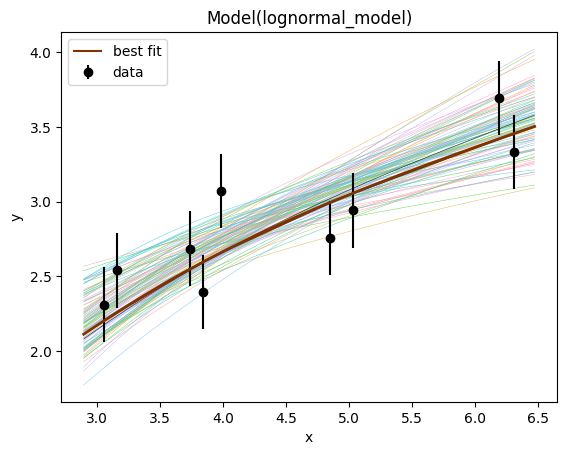

In [30]:
# Pastel colored lines for the posterior sample
my_palette = sns.husl_palette(n_colors=101, s=0.9, l=0.75, h=0.8)
# Reserve first two colormap entries for data and best fit, with darker colors
my_palette[0] = (0, 0, 0)
my_palette[1] = (0.5, 0.2, 0)
with my_palette:
    g = mcmc_result.plot_fit()
    xx = np.linspace(*g.get_xlim())
    for d in posterior_samples.to_dict(orient="records"):
        g.plot(xx, mcmc_result.eval(x=xx, **d), alpha=1, lw=0.3, zorder=-1)
    # Replot the fit line over the full range, making sure to use the same color
    g.plot(xx, mcmc_result.eval(x=xx), lw=2, color=sns.color_palette()[1])

These look a lot better than the bimodal ones. More similar to the powerlaw ones

## Corner plot of MCMC result for bimodal distro

In [33]:
red_cmap = sns.color_palette("light:#e84", n_colors=4)
red_cmap[0] = (1, 1, 1)
red_cmap

[(1, 1, 1),
 (0.9449376889402625, 0.805632002537177, 0.7147908602608168),
 (0.9391355111367979, 0.6694826679352552, 0.4907287634637417),
 (0.9333333333333333, 0.5333333333333333, 0.26666666666666666)]

In [34]:
samples = mcmc_result.flatchain[["log_n0", "log_nmu", "log_width"]]
samples

,log_n0,log_nmu,log_width
0,0.529001,0.938796,1.960773
1,1.098281,-2.898011,3.070867
2,0.249963,1.534507,1.859428
3,1.071211,2.253777,1.315695
4,1.571138,0.757043,1.576779
...,...,...,...
89995,1.189929,-2.635731,3.144706
89996,0.129872,1.843526,1.931971
89997,-1.821717,2.015206,1.818017
89998,1.817966,-0.030660,1.810000


### Uninformative prior

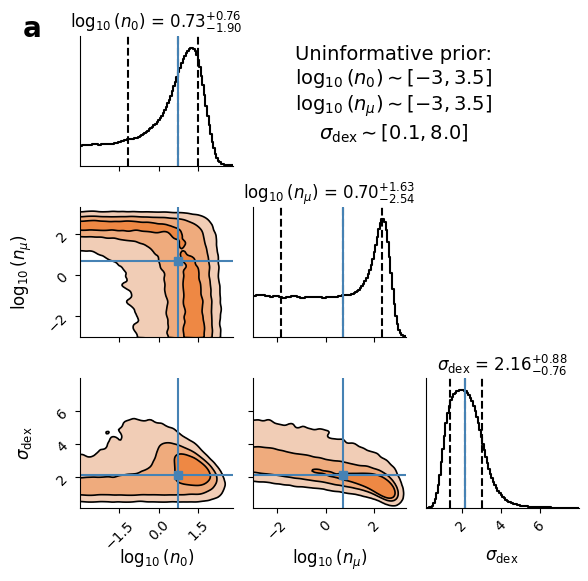

In [36]:
labels = [
    r"$\log_{10} (n_0)$",
    r"$\log_{10} (n_\mu)$",
    r"$\sigma_\mathrm{dex}$",
]
fig = corner.corner(
    samples,
    labels=labels,
    truths=[
        np.median(samples["log_n0"]),
        np.median(samples["log_nmu"]),
        np.median(samples["log_width"]),
    ],
    quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 12},
    bins=100,
    plot_datapoints=False,
    fill_contours=True,
    smooth=2,
    smooth1d=2,
    # Contours approximately enclosing 1, 2, 3 sigma for 2D Gaussian
    levels=(0.393, 0.865, 0.989),
    contour_kwargs={
        "linewidths": 1.2,
    },
    contourf_kwargs={
        # "cmap": "Reds",
        "colors": red_cmap,
    },
    # Axis/tick control
    max_n_ticks=4,
    top_ticks=False,
)
sns.despine()
fig.text(
    4/6, 
    5/6, 
    (
        "Uninformative prior:\n" 
        r"$\log_{10} (n_0) \sim [-3, 3.5]$" "\n"
        r"$\log_{10} (n_\mu) \sim [-3, 3.5]$" "\n"
        r"$\sigma_\mathrm{dex} \sim [0.1, 8.0]$" 
    ),
    ha="center",
    va="center",
    fontsize=14,
)
fig.text(0.08, 0.92, "a", ha="right", va="bottom", fontsize=20, fontweight="bold")
fig.set_size_inches(6.0, 6.0)
fig.tight_layout()
fig.savefig("lognormal-density-distribution-mcmc-corner-uniform.pdf")

In [30]:
ax.fill_betweenx?

Signature:
ax.fill_betweenx(
    y,
    x1,
    x2=0,
    where=None,
    step=None,
    interpolate=False,
    *,
    data=None,
    **kwargs,
)
Docstring:
Fill the area between two vertical curves.

The curves are defined by the points (*y*, *x1*) and (*y*,
*x2*).  This creates one or multiple polygons describing the filled
area.

You may exclude some vertical sections from filling using *where*.

By default, the edges connect the given points directly.  Use *step*
if the filling should be a step function, i.e. constant in between
*y*.

Parameters
----------
y : array-like
    The y coordinates of the nodes defining the curves.

x1 : array-like or float
    The x coordinates of the nodes defining the first curve.

x2 : array-like or float, default: 0
    The x coordinates of the nodes defining the second curve.

where : array-like of bool, optional
    Define *where* to exclude some vertical regions from being filled.
    The filled regions are defined by the coordinates ``y[where]``